# E337 - Grupo 1 - Trabajo Práctico 2
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

## Bibliotecas

In [29]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
!pip install xlrd

## Directorio

In [30]:
directorio = "/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP2"
os.chdir(directorio)
print(os.getcwd())

/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP2


## Limpieza de la base de datos

Nuestro objetivo aquí es limpiar y concatenar los dos data frames con todas sus variables. Para este paso, reutilizamos gran parte del código que habíamos escrito en el TP1, pero también hicimos algunos cambios; el código anterior estaba especificado para que solo hubiese 15 variables en el data frame nuevo, y aquí queremos incluir todas. 

In [31]:
# Abrimos las bases de datos
df_2005_raw = pd.read_stata('usu_individual_3105.dta', convert_categoricals=False, convert_missing=False)
df_2005_raw['EMPLEO'] = np.nan # Creamos la variable EMPLEO en la base del 2005 porque no está

df_2025_raw = pd.read_excel('usu_individual_T325.xls')

# Pasamos todas las variables a mayúsculas para armonizarlas:
df_2005_raw.columns = df_2005_raw.columns.str.upper().str.strip()
df_2025_raw.columns = df_2025_raw.columns.str.upper().str.strip()

# Filtramos por GBA
df_2005 = df_2005_raw[df_2005_raw['REGION'] == 1].copy()
df_2025 = df_2025_raw[df_2025_raw['REGION'] == 1].copy()

print(f"\nFiltro GBA")
print(f"  2005: {len(df_2005):,} observaciones")
print(f"  2025: {len(df_2025):,} observaciones")

# Ahora, forzamos el año:
df_2005['ANO4'] = 2005
df_2025['ANO4'] = 2025



Filtro GBA
  2005: 9,420 observaciones
  2025: 7,447 observaciones


Luego, toca convertir las variables categóricas a un mismo formato. Esta parte la hicimos con ayuda de la IA. 

In [32]:
# ============================================================
# ARMONIZACIÓN DE FORMATOS
# ============================================================

# --- PROBLEMA 1: Variables de ingresos con -9 sin limpiar en 2025 ---
vars_ingreso_extra = [
    'PP08D1', 'PP08F1', 'PP08F2', 'PP08J1', 'PP08J2', 'PP08J3',
    'TOT_P12', 'P47T', 'T_VI',
    'V3_M', 'V4_M', 'V8_M', 'V9_M', 'V10_M', 'V12_M', 'V18_M'
]

for col in vars_ingreso_extra:
    if col in df_2025.columns:
        df_2025.loc[df_2025[col] == -9, col] = np.nan

print("[1] -9 en variables de ingreso → NaN (2025)")


# --- PROBLEMA 2: Variables de código string vs float ---
def normalizar_codigo(serie):
    """Convierte string o float a string entero limpio. NaN se preserva."""
    def _conv(x):
        if pd.isna(x):
            return np.nan
        try:
            val = str(x).strip()
            if val == '' or val in ('nan', 'None'):
                return np.nan
            return str(int(float(val)))
        except:
            return np.nan
    return serie.apply(_conv)

vars_codigo = [
    'CH14', 'CH15_COD', 'CH16_COD',
    'PP04B_COD', 'PP04D_COD', 'PP11B_COD', 'PP11D_COD'
]

for col in vars_codigo:
    if col in df_2005.columns:
        df_2005[col] = normalizar_codigo(df_2005[col])
    if col in df_2025.columns:
        df_2025[col] = normalizar_codigo(df_2025[col])

print("[2] Variables de código normalizadas a string entero limpio")


# --- PROBLEMA 3: Variables de deciles con padding inconsistente ---
vars_deciles = [
    'DECOCUR', 'IDECOCUR', 'RDECOCUR', 'GDECOCUR', 'PDECOCUR', 'ADECOCUR',
    'DECINDR', 'IDECINDR', 'RDECINDR', 'GDECINDR', 'PDECINDR', 'ADECINDR',
    'DECIFR',  'IDECIFR',  'RDECIFR',  'GDECIFR',  'PDECIFR',  'ADECIFR',
    'DECCFR',  'IDECCFR',  'RDECCFR',  'GDECCFR',  'PDECCFR',  'ADECCFR'
]

for col in vars_deciles:
    if col in df_2005.columns:
        df_2005[col] = normalizar_codigo(df_2005[col])
    if col in df_2025.columns:
        df_2025[col] = normalizar_codigo(df_2025[col])

print("[3] Variables de deciles normalizadas")


# --- VERIFICACIÓN ---
print("\nVerificación post-armonización:")
for col in ['CH14', 'DECOCUR', 'PP04B_COD']:
    v05 = set(df_2005[col].dropna().unique()) if col in df_2005.columns else set()
    v25 = set(df_2025[col].dropna().unique()) if col in df_2025.columns else set()
    comunes = v05 & v25
    print(f"  {col}: {len(comunes)} valores en común entre bases")

[1] -9 en variables de ingreso → NaN (2025)
[2] Variables de código normalizadas a string entero limpio
[3] Variables de deciles normalizadas

Verificación post-armonización:
  CH14: 12 valores en común entre bases
  DECOCUR: 11 valores en común entre bases
  PP04B_COD: 29 valores en común entre bases


Ahora toca eliminar los valores sin sentido de la base de datos. Para esto, utilizamos ayuda de Claude. Le enviamos los diccionarios de ambos años y le pedimos que identificara potenciales valores sin sentido. A continuación, le pedimos un código que reemplazara los valores sin sentido por valores NaN. El chat completo de esta sección y demás chats en los que hayamos interactuado con la IA pueden hallarse en la parte III del informe. 

In [33]:
# --- Corrección de columnas con tipos mixtos ---

# CODUSU: código de hogar, es numérico
df_2005['CODUSU'] = pd.to_numeric(df_2005['CODUSU'], errors='coerce')
df_2025['CODUSU'] = pd.to_numeric(df_2025['CODUSU'], errors='coerce')

# PP09C_ESP: texto libre, se unifica como string (vacío si no hay dato)
df_2005['PP09C_ESP'] = df_2005['PP09C_ESP'].fillna('').astype(str).str.strip()
df_2025['PP09C_ESP'] = df_2025['PP09C_ESP'].fillna('').astype(str).str.strip()

# CH05: fecha de nacimiento, se unifica como string en formato dd/mm/yyyy
# CH05: fecha de nacimiento, se unifica como string en formato dd/mm/yyyy
# (puede no existir en todas las bases)
for df_temp in [df_2005, df_2025]:
    if 'CH05' in df_temp.columns:
        df_temp['CH05'] = df_temp['CH05'].astype(str).str.strip().replace('nan', np.nan)

# -----------------------------------------------------

# --- CH06: edad inválida ---
df_2005['CH06'] = df_2005['CH06'].replace(-1, np.nan)
df_2025['CH06'] = df_2025['CH06'].replace(-1, np.nan)

# --- CH07: estado civil Ns/Nr ---
df_2005['CH07'] = df_2005['CH07'].replace(9, np.nan)
df_2025['CH07'] = df_2025['CH07'].replace(9, np.nan)

# --- CH08: cobertura médica Ns/Nr ---
df_2005['CH08'] = df_2005['CH08'].replace(9, np.nan)
df_2025['CH08'] = df_2025['CH08'].replace(9, np.nan)

# --- CH14: Ns/Nr ---
df_2005['CH14'] = df_2005['CH14'].replace(99, np.nan)
df_2025['CH14'] = df_2025['CH14'].replace(99, np.nan)

# --- PP3E_TOT y PP3F_TOT: horas trabajadas, 999 = Ns/Nr ---
df_2005['PP3E_TOT'] = pd.to_numeric(df_2005['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3E_TOT'] = pd.to_numeric(df_2025['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2005['PP3F_TOT'] = pd.to_numeric(df_2005['PP3F_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3F_TOT'] = pd.to_numeric(df_2025['PP3F_TOT'], errors='coerce').replace(999, np.nan)

# --- NIVEL_ED: nivel educativo Ns/Nr ---
df_2005['NIVEL_ED'] = df_2005['NIVEL_ED'].replace(9, np.nan)
df_2025['NIVEL_ED'] = df_2025['NIVEL_ED'].replace(9, np.nan)

# --- CAT_OCUP: categoría ocupacional Ns/Nr ---
df_2005['CAT_OCUP'] = df_2005['CAT_OCUP'].replace(9, np.nan)
df_2025['CAT_OCUP'] = df_2025['CAT_OCUP'].replace(9, np.nan)

# --- PP04A: tipo de empresa ---
df_2005['PP04A'] = df_2005['PP04A'].replace({0: np.nan, 9: np.nan})
df_2025['PP04A'] = df_2025['PP04A'].replace({0: np.nan, 9: np.nan})

# --- P21: ingreso ocupación principal ---
df_2005.loc[df_2005['P21'] < 0, 'P21'] = np.nan
df_2025.loc[df_2025['P21'] < 0, 'P21'] = np.nan

# --- IPCF: ingreso per cápita familiar ---
df_2005.loc[df_2005['IPCF'] < 0, 'IPCF'] = np.nan
df_2025.loc[df_2025['IPCF'] < 0, 'IPCF'] = np.nan

# --- PP06C y PP06D: ingresos de independientes ---
for col in ['PP06C', 'PP06D']:
    for df_temp in [df_2005, df_2025]:
        if col in df_temp.columns:
            df_temp[col] = df_temp[col].replace({-7: np.nan, -8: np.nan, -9: np.nan})

# --- EMPLEO ---
if 'EMPLEO' in df_2025.columns:
    df_2025['EMPLEO'] = df_2025['EMPLEO'].replace(9, np.nan)

# --- PP3E_TOT y PP3F_TOT: horas trabajadas, 999 = Ns/Nr ---
df_2005['PP3E_TOT'] = pd.to_numeric(df_2005['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3E_TOT'] = pd.to_numeric(df_2025['PP3E_TOT'], errors='coerce').replace(999, np.nan)
df_2005['PP3F_TOT'] = pd.to_numeric(df_2005['PP3F_TOT'], errors='coerce').replace(999, np.nan)
df_2025['PP3F_TOT'] = pd.to_numeric(df_2025['PP3F_TOT'], errors='coerce').replace(999, np.nan)


El siguiente código lo agregamos debido a que habían ciertas inconsistencias entre las dos bases de la EPH. Para esto, utilizamos ayuda de la inteligencia artificial, específicamente de Claude.

In [34]:
# ============================================================
# ARMONIZACIÓN DE CODIFICACIÓN ENTRE 2005 Y 2025
# ============================================================

# --- INTENSI: recodificar 2005 al esquema de 2025 ---
# 2005: 1=SubocDemandante, 2=SubocNoDemandante, 3=OcupPleno, 4=Sobreocupado, 5=NoTrabajó, 9=Ns/Nr
# 2025: 1=Subocupado,      2=OcupPleno,         3=Sobreocupado, 4=NoTrabajó,    9=Ns/Nr
# Se fusionan las categorías 1 y 2 de 2005 (ambas subocupación) en la categoría 1 de 2025.
intensi_map_2005 = {
    1: 1,   # Subocupado demandante → Subocupado
    2: 1,   # Subocupado no demandante → Subocupado
    3: 2,   # Ocupado pleno → Ocupado pleno
    4: 3,   # Sobreocupado → Sobreocupado
    5: 4,   # No trabajó en la semana → No trabajó en la semana
    9: 9,   # Ns/Nr → Ns/Nr
    0: 0    # No corresponde → No corresponde
}
df_2005['INTENSI'] = df_2005['INTENSI'].map(intensi_map_2005)
print("[4] INTENSI recodificado de 2005 al esquema 2025")


# --- PP04G: recodificar 2005 al esquema de 2025 ---
# En 2005, código 1 = "local/oficina/establecimiento/negocio/taller/chacra/finca" (todo junto).
# En 2025, se desagregó en: 11=local/oficina/taller, 12=vivienda con lugar exclusivo, 13=chacra/finca.
# Como no es posible desagregar el viejo código 1, se mapea a 11 (la subcategoría más común en GBA).
# Los demás códigos (2-10) son idénticos.
df_2005.loc[df_2005['PP04G'] == 1, 'PP04G'] = 11
print("[5] PP04G código 1 (2005) → 11 (esquema 2025)")


# --- PP07E: en 2005 existía 1="plan de empleo", eliminado en 2025 ---
# En 2025 solo existen 2=período de prueba, 3=beca/pasantía, 4=ninguno.
# Opciones: (a) dejar el 1 como está (categoría exclusiva de 2005),
#           (b) recodificarlo a NaN.
# Elegimos (a) para no perder información; pero si se necesita comparabilidad estricta, usar (b).
# Descomentar la línea siguiente para opción (b):
# df_2005.loc[df_2005['PP07E'] == 1, 'PP07E'] = np.nan
print("[6] PP07E: código 1 (plan de empleo) solo existe en 2005 — sin cambio")


# --- PP11M: en 2005 existía 1="plan de empleo", eliminado en 2025 ---
# Misma situación que PP07E.
# Descomentar para convertir a NaN si se desea comparabilidad estricta:
# df_2005.loc[df_2005['PP11M'] == 1, 'PP11M'] = np.nan
print("[7] PP11M: código 1 (plan de empleo) solo existe en 2005 — sin cambio")


# --- PP11L1: pregunta diferente entre años ---
# 2005: "¿Ese trabajo era... 1=changa/transitorio, 2=permanente, 3=Ns/Nr?"
# 2025: "¿Cobraba algún plan? 1=Sí, 2=No"
# NO SON COMPARABLES. Se recodifica 2005 a NaN para evitar confusión.
df_2005['PP11L1'] = np.nan
print("[8] PP11L1: pregunta incompatible entre años → NaN en 2005")


# --- Verificación final ---
print("\nVerificación post-armonización de codificación:")
for col in ['INTENSI', 'PP04G']:
    v05 = set(df_2005[col].dropna().unique())
    v25 = set(df_2025[col].dropna().unique())
    print(f"  {col}:")
    print(f"    2005 (recodificado): {sorted(v05)}")
    print(f"    2025:                {sorted(v25)}")

[4] INTENSI recodificado de 2005 al esquema 2025
[5] PP04G código 1 (2005) → 11 (esquema 2025)
[6] PP07E: código 1 (plan de empleo) solo existe en 2005 — sin cambio
[7] PP11M: código 1 (plan de empleo) solo existe en 2005 — sin cambio
[8] PP11L1: pregunta incompatible entre años → NaN en 2005

Verificación post-armonización de codificación:
  INTENSI:
    2005 (recodificado): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(9)]
    2025:                [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  PP04G:
    2005 (recodificado): [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(99.0)]
    2025:                [np.float64(0.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float6

In [35]:
# Concatenamos los dataframes
df_final = pd.concat([df_2005, df_2025], ignore_index=True)

# Finalmente, guardamos la base df_final combinada como csv. 

df_final.to_csv('eph_gba_merged_full.csv', index=False)
print("\nBase guardada como 'eph_gba_merged_full.csv'")



Base guardada como 'eph_gba_merged_full.csv'


### Ejercicio 1


In [36]:
# Abrimos el csv. Tuvimos que hacer ciertas correcciones como para no tener un warning.
df_eph_GBA = pd.read_csv('eph_gba_merged_full.csv', dtype={
    'CODUSU': 'float64',   # numérico (float para tolerar NaN)
    'PP09C_ESP': 'object', # texto
    'CH05': 'object'       # texto (fechas como string)
})

In [37]:
df_eph_GBA["edad2"] = (df_eph_GBA["CH06"])**2

In [38]:
# Para esta parte, reutilizaremos el código del TP1. 

norespondieron = df_eph_GBA [df_eph_GBA['ESTADO'] == 0].copy()
respondieron   =df_eph_GBA [df_eph_GBA['ESTADO'] != 0].copy()

print("No respondieron (ESTADO = 0):", len(norespondieron))
print("Respondieron    (ESTADO ≠ 0):", len(respondieron))

ocupados = respondieron[respondieron['ESTADO'] == 1].copy()

print("Ocupados (ESTADO = 1):", len(ocupados))

ocupados['informal'] = 0

ocupados.loc[(ocupados['CAT_OCUP'] == 3) & (ocupados['PP07H'] == 2), 'informal'] = 1
ocupados.loc[ocupados['CAT_OCUP'] == 4, 'informal'] = 1

print("Formales  (informal = 0):", (ocupados['informal'] == 0).sum())
print("Informales (informal = 1):", (ocupados['informal'] == 1).sum())
print("Tasa de informalidad:", round((ocupados['informal'] == 1).sum() / len(ocupados) * 100, 1), "%")

No respondieron (ESTADO = 0): 24
Respondieron    (ESTADO ≠ 0): 16843
Ocupados (ESTADO = 1): 7625
Formales  (informal = 0): 5288
Informales (informal = 1): 2337
Tasa de informalidad: 30.6 %


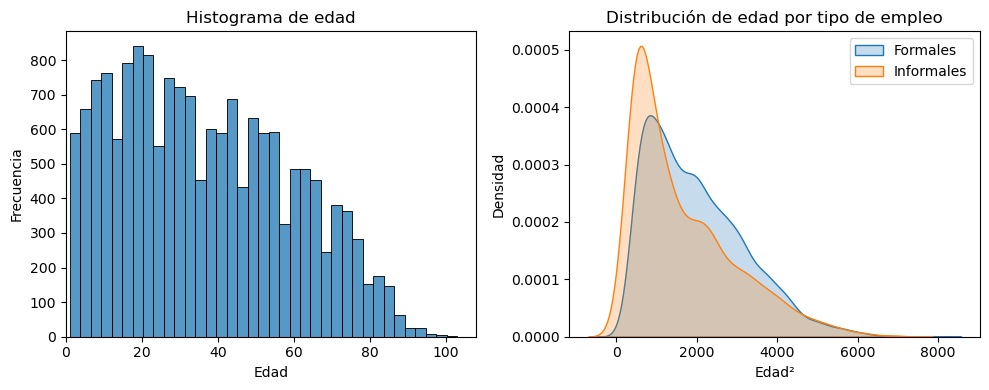

In [39]:
# Ahora, realizaremos el histograma  de la variable edad en un panel A, y la distribución de kernels para los trabajadores formales e informales en un panel B.

data_edad = df_eph_GBA["CH06"]
data_edad2 = df_eph_GBA["edad2"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(data_edad, ax=axes[0])
axes[0].set_xlim(left=0)
axes[0].set_title("Histograma de edad")


axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(left=0)


axes[1].set_title("Densidad de Kernel (KDE)")
formales = ocupados [ocupados["informal"] == 0]["edad2"]
informales = ocupados [ocupados["informal"] == 1]["edad2"]
sns.kdeplot(formales,   fill=True, label="Formales",   ax=axes[1])
sns.kdeplot(informales, fill=True, label="Informales", ax=axes[1])

axes[1].set_xlabel("Edad²")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución de edad por tipo de empleo")
axes[1].legend()


plt.tight_layout()
plt.savefig('Histograma y DistKernel.png', bbox_inches='tight', dpi=300)
plt.show()



### Ejercicio 2

In [40]:
# El objetivo es crear la variable "educ".

# Primero, convertimos las variables a valores numéricos:
df_eph_GBA['CH12'] = pd.to_numeric(df_eph_GBA['CH12'], errors='coerce')
df_eph_GBA['CH13'] = pd.to_numeric(df_eph_GBA['CH13'], errors='coerce')
df_eph_GBA['CH14'] = pd.to_numeric(df_eph_GBA['CH14'], errors='coerce')

# Creamos "educ" según si se finalizó o no el nivel:
df_eph_GBA['educ'] = np.nan

# Si el individuo finalizó (CH13 == 1): años totales del nivel
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 1) & (df_eph_GBA['CH13'] == 1), 'educ'] = 0
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 2) & (df_eph_GBA['CH13'] == 1), 'educ'] = 6
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 3) & (df_eph_GBA['CH13'] == 1), 'educ'] = 9
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 4) & (df_eph_GBA['CH13'] == 1), 'educ'] = 12
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 5) & (df_eph_GBA['CH13'] == 1), 'educ'] = 12
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 6) & (df_eph_GBA['CH13'] == 1), 'educ'] = 15
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 7) & (df_eph_GBA['CH13'] == 1), 'educ'] = 17
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 8) & (df_eph_GBA['CH13'] == 1), 'educ'] = 20

# Si el individuo no finalizó (CH13 == 2): base del nivel + años cursados (CH14)
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 1) & (df_eph_GBA['CH13'] == 2), 'educ'] = 0  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 2) & (df_eph_GBA['CH13'] == 2), 'educ'] = 0  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 3) & (df_eph_GBA['CH13'] == 2), 'educ'] = 0  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 4) & (df_eph_GBA['CH13'] == 2), 'educ'] = 6  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 5) & (df_eph_GBA['CH13'] == 2), 'educ'] = 6  + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 6) & (df_eph_GBA['CH13'] == 2), 'educ'] = 12 + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 7) & (df_eph_GBA['CH13'] == 2), 'educ'] = 12 + df_eph_GBA['CH14']
df_eph_GBA.loc[(df_eph_GBA['CH12'] == 8) & (df_eph_GBA['CH13'] == 2), 'educ'] = 17 + df_eph_GBA['CH14']

# Estadística descriptiva
print(df_eph_GBA['educ'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))

mean       10.61
std        12.31
min         0.00
median      9.00
max       116.00
Name: educ, dtype: float64


### Ejercicio 3

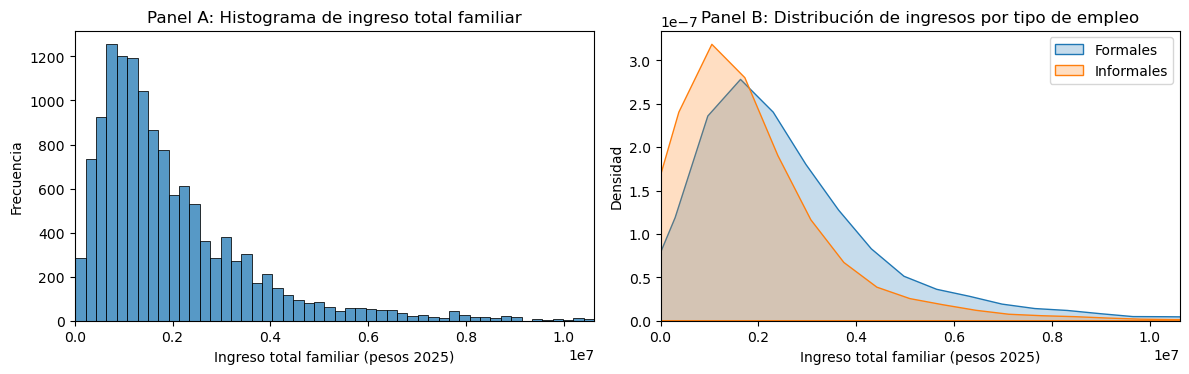

mean      2.112352e+06
std       3.191931e+06
min       1.000000e+04
median    1.500000e+06
max       1.296000e+08
Name: ingreso_total_familiar, dtype: float64
mean      2.112352e+06
std       3.191931e+06
min       1.000000e+04
median    1.500000e+06
max       1.296000e+08
Name: ingreso_total_familiar, dtype: float64


In [41]:
# Para actualizar la variable ingreso_total_familiar, necesitamos actualizar el valor de inflación.
# Como la inflación acumulada de Argentina entre 2005 y 2025 fue de aproximadamente 120.000 %, 
## vamos a deflactar según ese valor. 

factor = 1200

# Creamos la variable
df_eph_GBA['ingreso_total_familiar'] = np.where(
    df_eph_GBA['ANO4'] == 2005,
    df_eph_GBA['ITF'] * factor,
    df_eph_GBA['ITF']
)
df_eph_GBA.loc[df_eph_GBA['ingreso_total_familiar'] <= 0, 'ingreso_total_familiar'] = np.nan

# Definimos limite (ahora sí existe la variable)
limite = df_eph_GBA['ingreso_total_familiar'].quantile(0.99)

# Armamos el histograma
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

datos_histograma = df_eph_GBA['ingreso_total_familiar'].dropna()
datos_histograma = datos_histograma[datos_histograma <= limite]

sns.histplot(datos_histograma, ax=axes[0], bins=50)
axes[0].set_title("Panel A: Histograma de ingreso total familiar")
axes[0].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_xlim(0, limite)

# Kernel por formal/informal
ocupados['ingreso_total_familiar'] = ocupados['ITF'].copy()
ocupados.loc[ocupados['ANO4'] == 2005, 'ingreso_total_familiar'] = ocupados['ITF'] * factor
ocupados.loc[ocupados['ingreso_total_familiar'] <= 0, 'ingreso_total_familiar'] = np.nan

formales   = ocupados[ocupados['informal'] == 0]['ingreso_total_familiar'].dropna()
informales = ocupados[ocupados['informal'] == 1]['ingreso_total_familiar'].dropna()

sns.kdeplot(formales,   fill=True, label='Formales',   ax=axes[1])
sns.kdeplot(informales, fill=True, label='Informales', ax=axes[1])
axes[1].set_title("Panel B: Distribución de ingresos por tipo de empleo")
axes[1].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[1].set_ylabel("Densidad")
axes[1].set_xlim(0, limite)
axes[1].legend()

plt.tight_layout()
plt.savefig('Histograma_Ingresos_y_DistKernel.png', bbox_inches='tight', dpi=300)
plt.show()

# Estadística descriptiva
print(df_eph_GBA['ingreso_total_familiar'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))
print(df_eph_GBA['ingreso_total_familiar'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))

### Ejercicio 4

In [42]:
# El objetivo es crear la variable horastrab como el total de horas trabajadas como la suma de las horas en la ocupación
## principal y otras ocupaciones.

jefes = df_eph_GBA[df_eph_GBA['CH03'] == 1].copy()
jefes['horastrab'] = jefes['PP3E_TOT'] + jefes['PP3F_TOT']
print(jefes['horastrab'].agg(['mean', 'std', 'min', 'median', 'max']).round(2))


mean       33.75
std        24.10
min         0.00
median     40.00
max       122.00
Name: horastrab, dtype: float64


### Ejercicio 5

In [43]:
# Informal: la variable vive en 'ocupados', la pegamos a df_eph_GBA
df_eph_GBA['informal'] = np.nan
df_eph_GBA.loc[ocupados.index, 'informal'] = ocupados['informal']

# Separamos df_eph_GBA por año
df_2005_final = df_eph_GBA[df_eph_GBA['ANO4'] == 2005]
df_2025_final = df_eph_GBA[df_eph_GBA['ANO4'] == 2025]

# Cantidad de observaciones
obs_2005  = len(df_2005_final)
obs_2025  = len(df_2025_final)
obs_total = len(df_eph_GBA)

# NaNs en informal por año
na_inf_2005  = df_2005_final['informal'].isna().sum()
na_inf_2025  = df_2025_final['informal'].isna().sum()
na_inf_total = df_eph_GBA['informal'].isna().sum()

# Informales por año
inf_2005  = (df_2005_final['informal'] == 1).sum()
inf_2025  = (df_2025_final['informal'] == 1).sum()
inf_total = (df_eph_GBA['informal'] == 1).sum()

# Formales por año
for_2005  = (df_2005_final['informal'] == 0).sum()
for_2025  = (df_2025_final['informal'] == 0).sum()
for_total = (df_eph_GBA['informal'] == 0).sum()

# Cantidad de variables limpias y homogeneizadas
vars_limpias = len(df_eph_GBA.columns)

# Imprimimos tabla
print(f"{'':45} {'2005':>8} {'2025':>8} {'Total':>8}")
print("-" * 71)
print(f"{'Cantidad de observaciones':45} {obs_2005:>8} {obs_2025:>8} {obs_total:>8}")
print(f"{'Obs. con NAs en Informal':45} {na_inf_2005:>8} {na_inf_2025:>8} {na_inf_total:>8}")
print(f"{'Cantidad de Informales':45} {inf_2005:>8} {inf_2025:>8} {inf_total:>8}")
print(f"{'Cantidad de Formales':45} {for_2005:>8} {for_2025:>8} {for_total:>8}")
print(f"{'Cantidad de variables limpias y homogeneizadas':45} {vars_limpias:>8} {vars_limpias:>8} {vars_limpias:>8}")

                                                  2005     2025    Total
-----------------------------------------------------------------------
Cantidad de observaciones                         9420     7447    16867
Obs. con NAs en Informal                          5332     3910     9242
Cantidad de Informales                            1412      925     2337
Cantidad de Formales                              2676     2612     5288
Cantidad de variables limpias y homogeneizadas      247      247      247


# Parte II: Métodos No Supervisados

### Ejercicio 1

## PCA

### Ejercicio 2

### Ejercicio 3

### Ejercicio 4

## Cluster

### Ejercicio 5

#### Inciso a

#### Inciso b

### Ejercicio 6

### Ejercicio 7

# Parte III: Herramientas de IA y reflexión final


Realizado en documento de LaTeX. 